In [1]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
import rasterio
from pathlib import Path
import gdal_tools

#model outputs
#path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/'
#path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/'
path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/'
path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/'


#path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
#path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/"
#path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/'


#satelite dat
smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"
#Ndmi_sat = '/scratch/alpine/battobrah@xsede.org/landsat_ndmi/NORTHERN_NM_MONTHLY_PER_YEAR_2014_2024/'

print(path_pp)
print(path_3d)


outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/test_K7"
os.makedirs(outputdir, exist_ok=True)

path = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/'


# ------------------------------------
# READ TIME FROM INPUT FILE (REQUIRED)
# ------------------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

# ------------------------------------
# BUILD DATETIME VECTOR (PROF STYLE)
# ------------------------------------
start = pd.Timestamp("2016-01-01 00:00")

datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")


# Read HRU grid + metadata (Read spatial rasters that map grid cells to HRUs)
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250     #trim off 250 pixels around the edges of the domain.
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)   # read cluster ids

# Force HRU count to match model outputs (1000)
with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):      # read raster grid
    with rasterio.open(fp) as ds:
        arr = ds.read(1).astype(np.float32)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr
      
def place_data(tmp, model, hrus, cids, val):    #tmp: an empty 2D grid template
    out = np.copy(tmp)                          #a 1D array of HRU values from the model
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru  = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/
/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


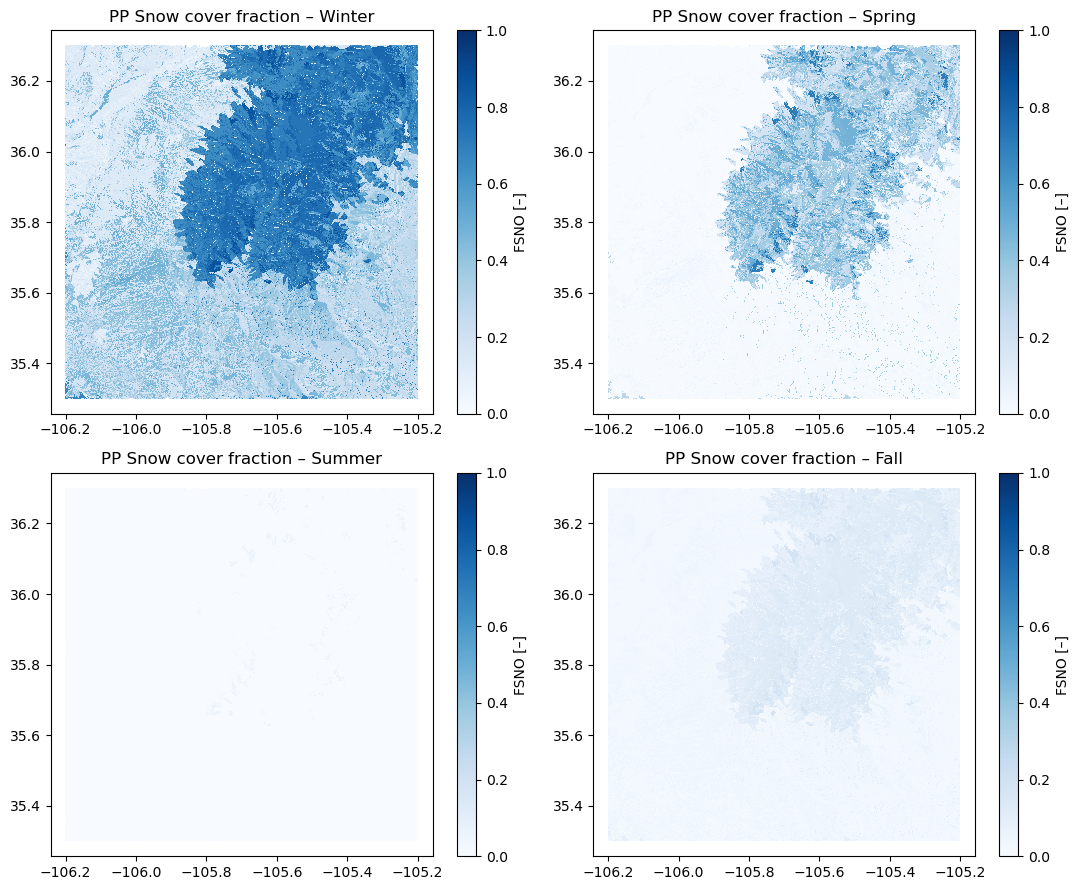

In [2]:
# snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors  # <-- add if not already imported

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# FIXED scale so that 0 is always the reference for no snow
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=fsno_norm,          # <-- added: fixed 0–1 scale
        shading="auto"
    )

    ax.set_title(f"PP Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp.png"),
    dpi=300
)
plt.show()


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


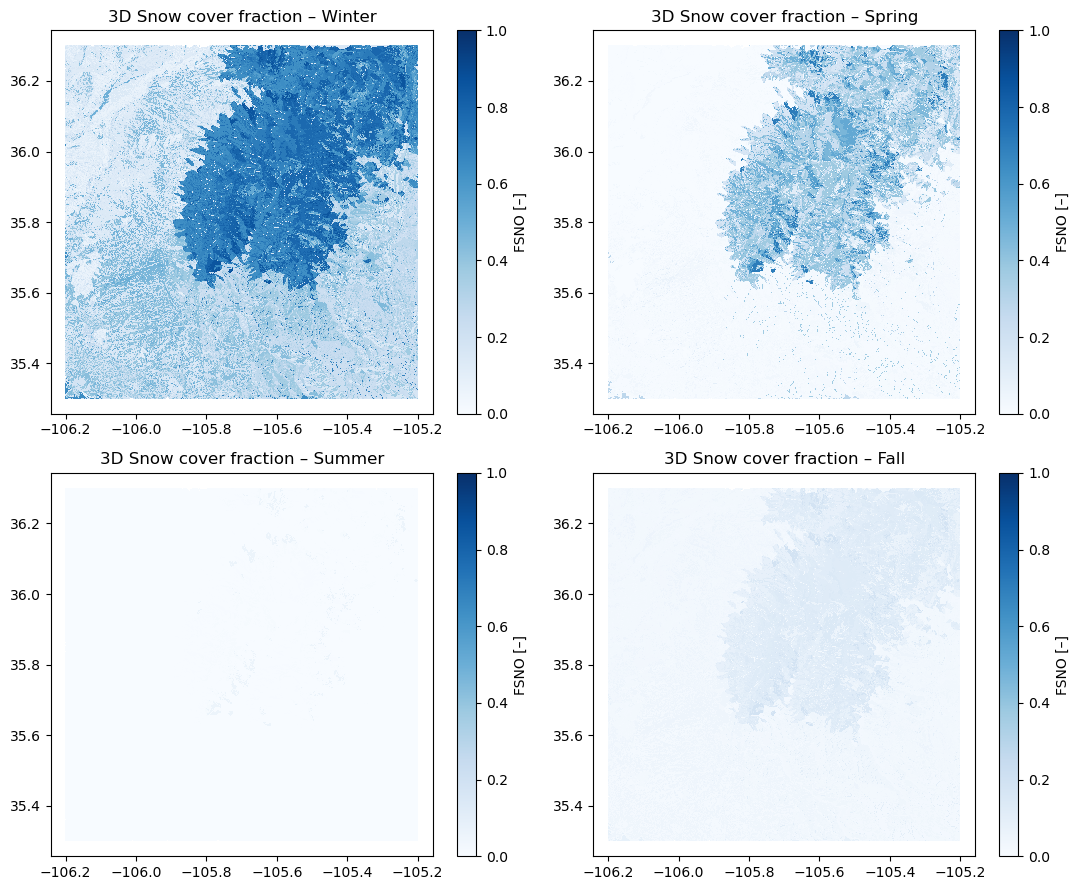

In [3]:
# snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors  # <-- add if not already imported

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# FIXED scale so that 0 is always the reference for no snow
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=fsno_norm,          # <-- added: fixed 0–1 scale
        shading="auto"
    )

    ax.set_title(f"3D Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_3d.png"),
    dpi=300
)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


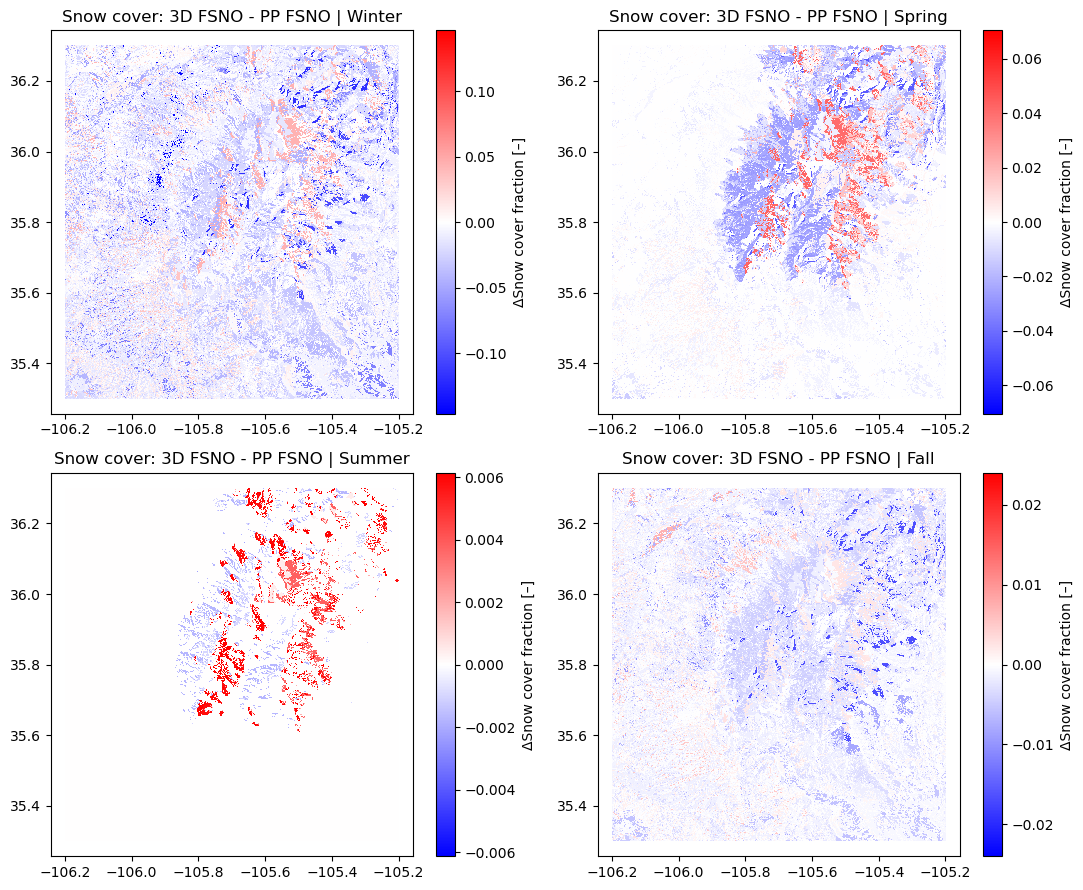

In [21]:
# 3D - PP seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  PP FSNO

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("PP:", path_pp)

# use 3D domain for mapping (hrus/cids should match; we map both to the same grid)
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):     #seasons (0,1,2,3)
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # seasonal mask (same for both)
    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    # ----------------------------
    # 3D seasonal mean FSNO (HRU)
    # ----------------------------
    fp_3d  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    fsno_3d_ave = np.nanmean(fsno_3d[times_index, :], axis=0)  # (hru,)
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # ----------------------------
    # PP seasonal mean FSNO (HRU)
    # ----------------------------
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    fsno_pp_ave = np.nanmean(fsno_pp[times_index, :], axis=0)  # (hru,)
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.where(map_pp == -9999, np.nan, map_pp)

    # ----------------------------
    # remove buffer (both)
    # ----------------------------
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]

    # difference: 3D - PP
    final_map = map_3d - map_pp

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - PP FSNO | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3D_minus_PP_FSNO_maps.png"), dpi=300)
plt.show()


3D vs PP: Winter
3D vs PP: Spring
3D vs PP: Summer
3D vs PP: Fall


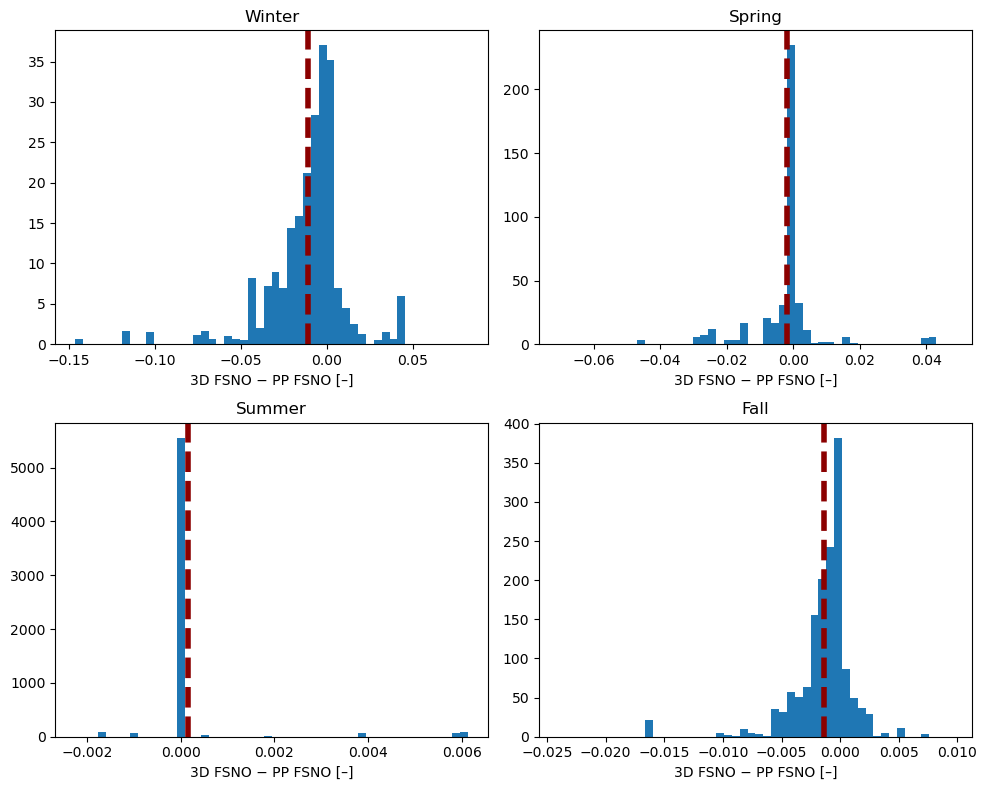

In [22]:
# 3D vs PP difference Histogram Plot (Snow cover fraction)
# Difference = 3D FSNO - PP FSNO

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # -------------------------
    # 3D seasonal mean FSNO (HRU)
    # -------------------------
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)

    # map 3D HRU → grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # PP seasonal mean FSNO (HRU)
    # -------------------------
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)

    # map PP HRU → grid (onto SAME grid)
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    diff = fsno_3d_grid - fsno_pp_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − PP FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_snow_3D_minus_PP_FSNO.png"),
    dpi=300
)
plt.show()


PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating differences plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2860302241.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Spring
Creating differences plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2860302241.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Fall


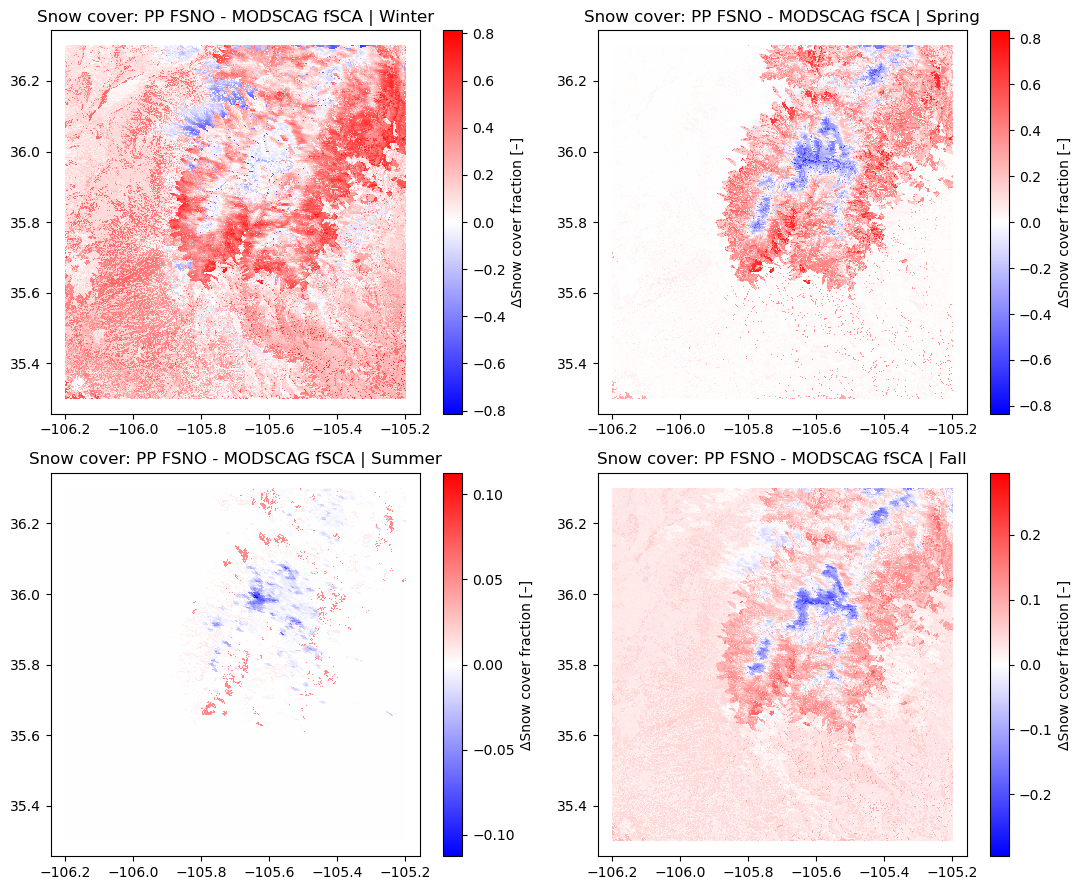

In [23]:
# PP - modscag seasonal difference maps (Snow cover fraction)
# Difference = PP FSNO  -  MODSCAG fSCA

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import xarray as xr

print("PP:", path_pp)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# use PP domain for mapping
path = path_pp

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODSCAG monthly files (your filenames)
#pat = re.compile(r".*MODSCAG_HBclip_ALLVARS_(\d{4})_(\d{2})_MODELGRID_4326\.nc$")
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)

    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODSCAG already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modscag_rows = build_modscag_rows(modscag_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # PP model seasonal mean FSNO in HRU space
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_pp_sel = fsno_pp[times_index, :]
    fsno_pp_ave = np.nanmean(fsno_pp_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.ma.masked_array(map_pp, map_pp == -9999)
    map_pp[map_pp == -9999] = np.nan

    # MOODCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_pp.shape
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert % -> fraction
    modscag_map = modscag_map / 100.0
    
    # difference: PP - MODSCAG
    final_map = map_pp - modscag_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: PP FSNO - MODSCAG fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_PP_minus_MODSCAG_fSCA_maps.png"), dpi=300)
plt.show()


modscag vs PP: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/101006637.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs PP: Spring
modscag vs PP: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/101006637.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs PP: Fall


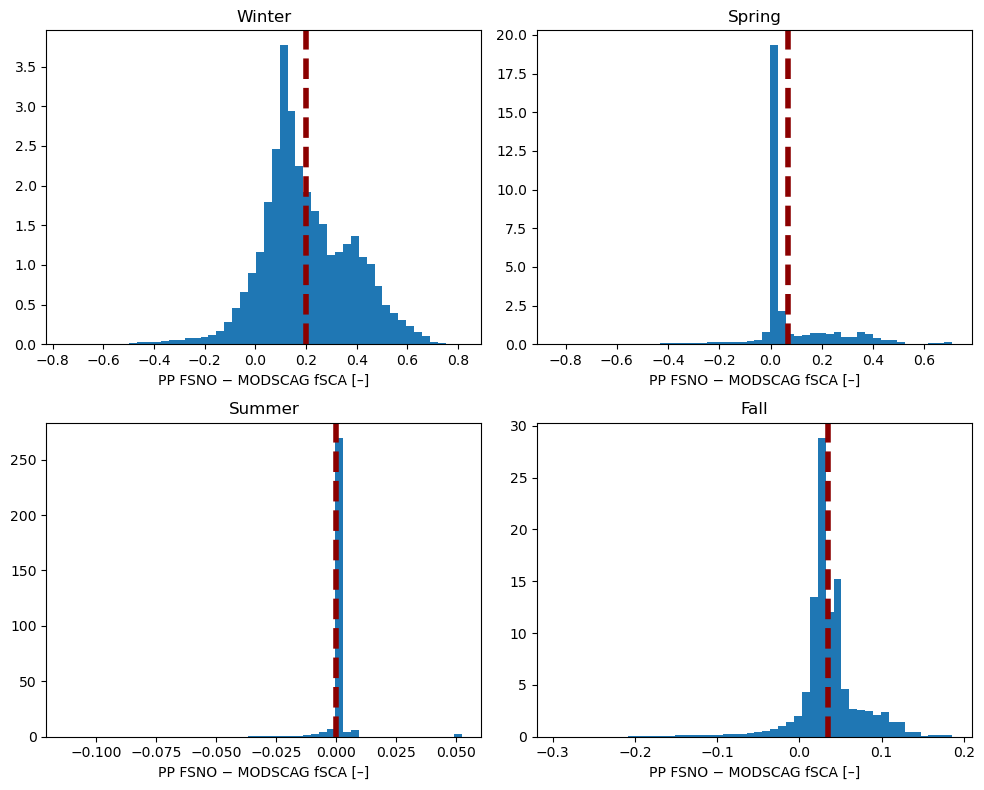

In [24]:
# PP vs MODSCAG difference Histogram Plot (Snow cover fraction)

path_domain = path_pp  # <-- changed (was path_3d)

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modscag_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No modscag files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"modscag vs PP: {my_season}")  # <-- changed label

    # PP seasonal mean FSNO (HRU space)
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")  # <-- changed (was path_3d)
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)  # <-- changed name

    # MODSCAG seasonal mean (grid, already on model grid)
    modscag_grid = modscag_season_mean_grid(modscag_rows, my_months)

    # convert percent → fraction
    modscag_grid = modscag_grid / 100.0

    modscag_grid = modscag_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map PP HRU → grid
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)  # <-- changed
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno_pp_grid - modscag_grid  # <-- PP - MODCAG
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("PP FSNO − MODSCAG fSCA [–]")  # <-- changed

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_PP_minus_MODSCAG_fSCA.png"),  # <-- changed filename
    dpi=300
)
plt.show()


3d: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating differences plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/4238867370.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Spring
Creating differences plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/4238867370.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Fall


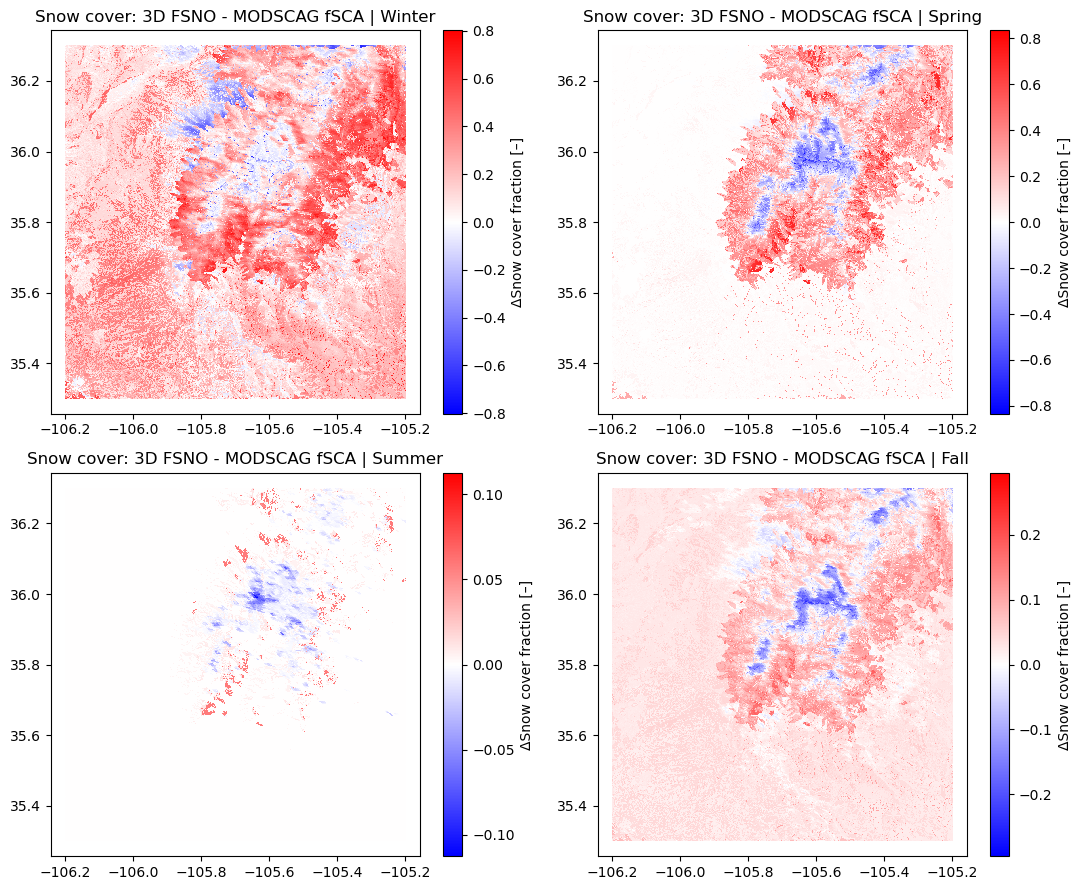

In [25]:
# 3d - modscag seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  MODSCAG fSCA

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import xarray as xr

print("3d:", path_3d)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# use 3d domain for mapping
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODSCAG monthly files (your filenames)
#pat = re.compile(r".*MODSCAG_HBclip_ALLVARS_(\d{4})_(\d{2})_MODELGRID_4326\.nc$")
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)

    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODSCAG already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modscag_rows = build_modscag_rows(modscag_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # 3d model seasonal mean FSNO in HRU space
    fp_3s  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d[map_3d == -9999] = np.nan

    # MOODCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert % -> fraction
    modscag_map = modscag_map / 100.0
    
    # difference: 3d - MODSCAG
    final_map = map_3d - modscag_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - MODSCAG fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3d_minus_MODSCAG_fSCA_maps.png"), dpi=300)
plt.show()


modscag vs 3d: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2545703539.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs 3d: Spring
modscag vs 3d: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2545703539.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs 3d: Fall


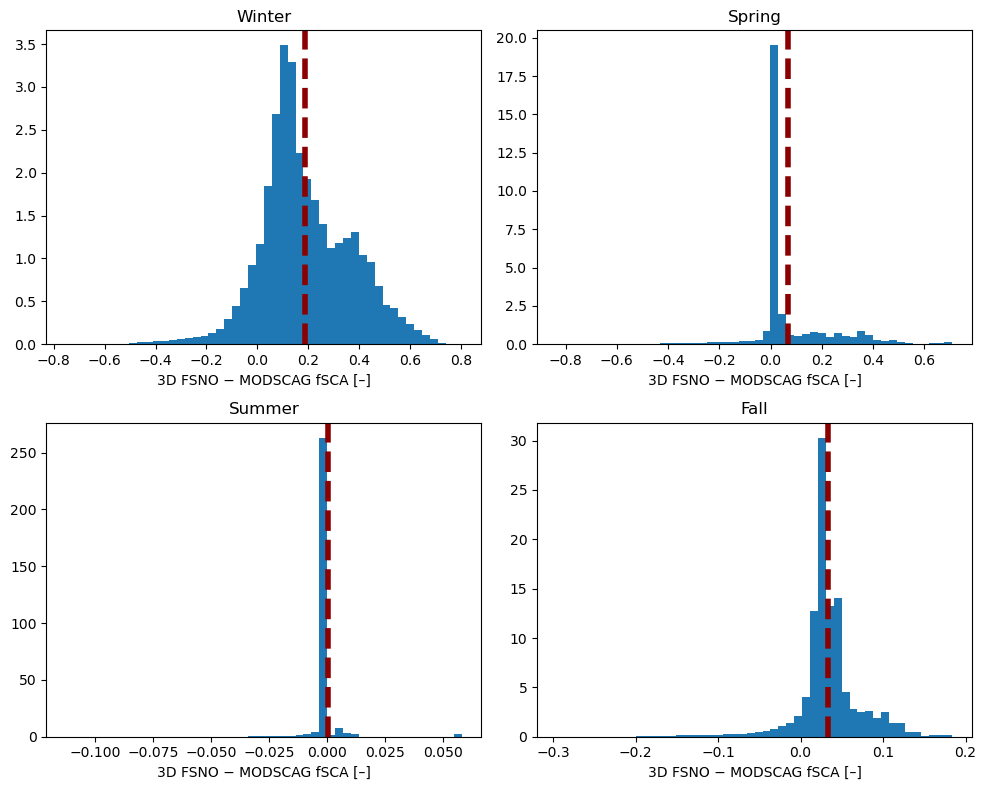

In [26]:
# 3D vs MODSCAG difference Histogram Plot (Snow cover fraction)

path_domain = path_3d  # <-- changed (was path_3d)

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modscag_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No modscag files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"modscag vs 3d: {my_season}")  # <-- changed label

    # 3d seasonal mean FSNO (HRU space)
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")  # <-- changed (was path_3d)
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)  # <-- changed name

    # MODSCAG seasonal mean (grid, already on model grid)
    modscag_grid = modscag_season_mean_grid(modscag_rows, my_months)

    # convert percent → fraction
    modscag_grid = modscag_grid / 100.0

    modscag_grid = modscag_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map 3d HRU → grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)  # <-- changed
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno_3d_grid - modscag_grid  # <-- 3D - MODSCAG
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − MODSCAG fSCA [–]")  # <-- changed

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_3D_minus_MODSCAG_fSCA.png"),  # <-- changed filename
    dpi=300
)
plt.show()


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/1465797900.py:62: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/1465797900.py:62: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


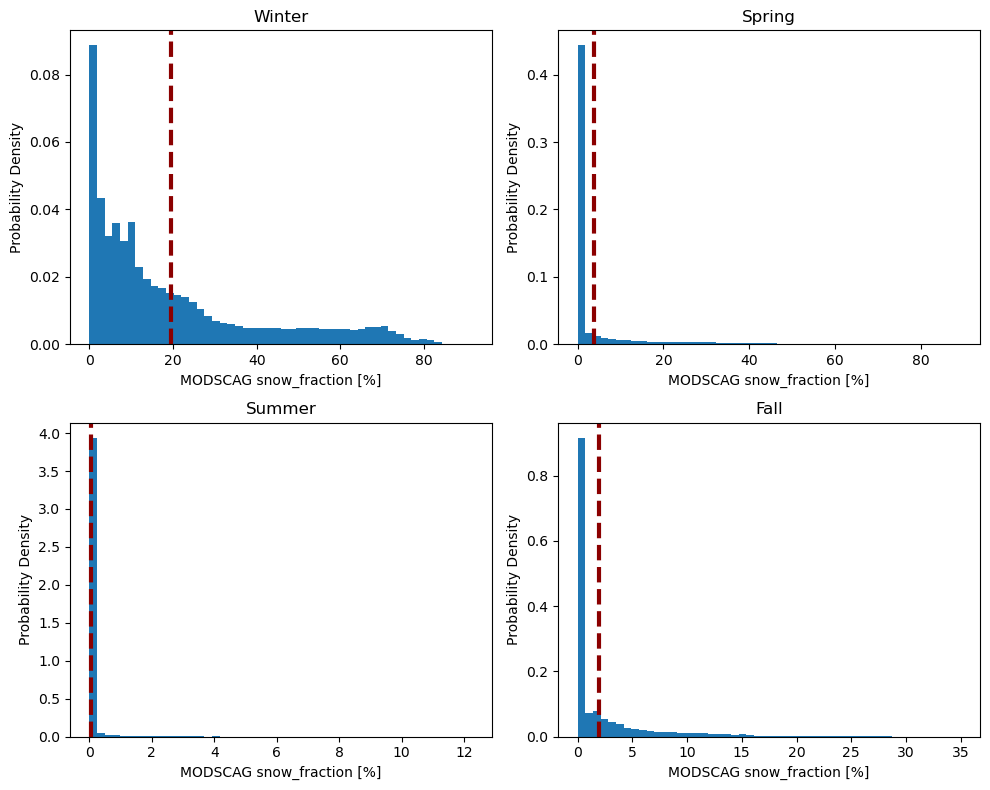

In [27]:
import os
import glob, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# INPUT folder (same as your script)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

# OUTPUT folder
try:
    outputdir
except NameError:
    outputdir = modscag_sat
os.makedirs(outputdir, exist_ok=True)

# File pattern (same as your script)
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        if yyyy < 2016 or yyyy > 2018:
            continue
        rows.append((pd.Timestamp(yyyy, mm, 1), fp))
    rows.sort(key=lambda x: x[0])
    return rows

def read_snow_fraction(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]
    da = da.where(da != 255).where(da != -9999)  # remove fill values
    arr = da.values.astype("float32")
    ds.close()
    return arr

def read_grid(fp):
    # Read MODSCAG snow_fraction from the monthly NetCDF on HB grid
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle common fill values (MODSCAG original fill is 255; your processing may also use -9999)
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, months):
    arrs = [read_snow_fraction(fp) for dt, fp in rows if dt.month in months]
    if not arrs:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

# --- seasonal histograms ---
import pandas as pd  # needed for Timestamp above

rows = build_modscag_rows(modscag_sat)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, months) in enumerate(zip(seasons, season_months)):
    season_map = modscag_season_mean(rows, months)
    if season_map is None:
        axes[i].axis("off")
        continue

    arr = season_map.ravel()
    arr = arr[np.isfinite(arr)]

    axes[i].hist(arr, bins=50, density=True)
    axes[i].axvline(np.mean(arr), linestyle="dashed", linewidth=3, color="darkred")
    axes[i].set_title(name)
    axes[i].set_xlabel("MODSCAG snow_fraction [%]")
    axes[i].set_ylabel("Probability Density")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_hist_MODSCAG_snow_fraction_seasonal.png"), dpi=300)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


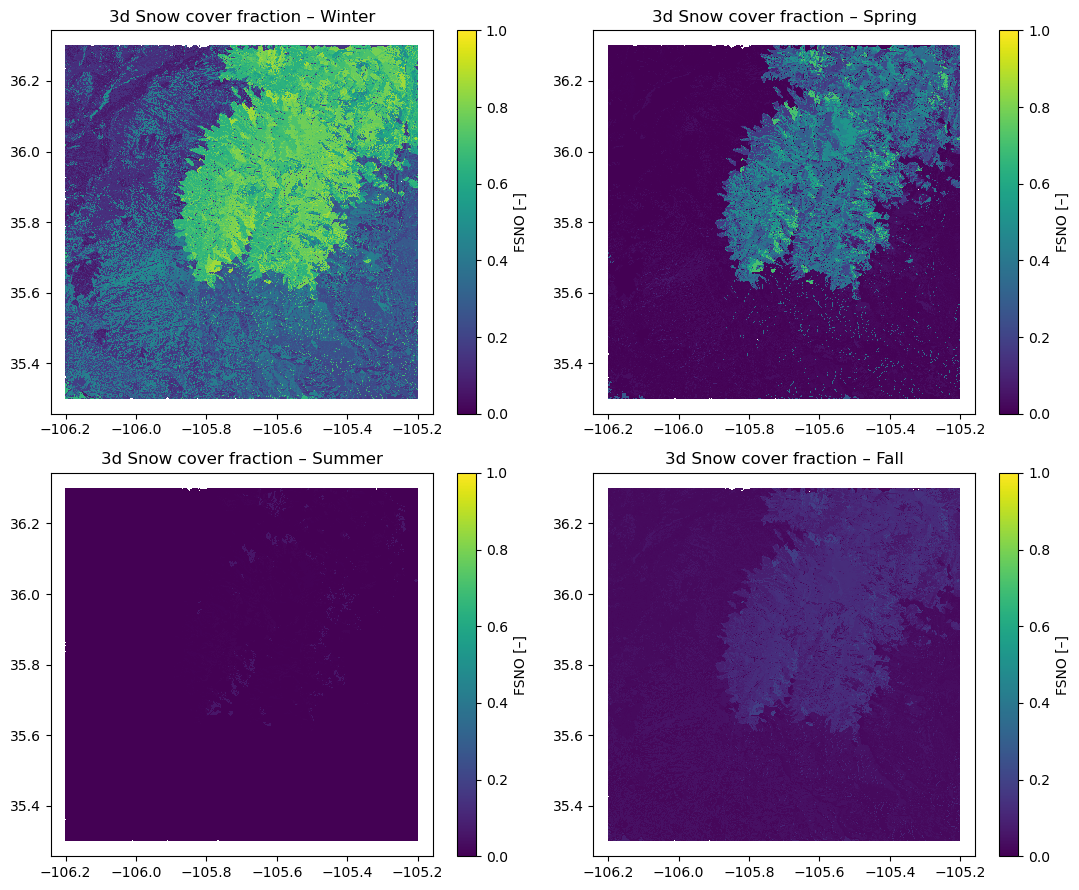

In [32]:
# snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors

#path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_2/MSWX_3h_Snow_Project3_pp/"
path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/'

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        nt = fsno.shape[0]
        fp.close()

        # build matching datetime vector for THIS variable length
        start = pd.Timestamp("2016-01-01 00:00")
        times_local = pd.Series(
            (start + pd.to_timedelta(np.arange(nt) * 3, unit="h"))
            .tz_localize("UTC")
            .tz_convert("America/Denver"),
            name="datetime"
        )

        # Seasonal mask
        times_index = (
            (times_local.dt.month == my_months[0]) |
            (times_local.dt.month == my_months[1]) |
            (times_local.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index.values, :]      # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # fresh template each loop
        tmp = np.copy(hrus)
        tmp[:] = -9999.0

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map.astype(float)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"3d Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp.png"),
    dpi=300
)
plt.show()

In [30]:
import netCDF4 as nc


import netCDF4 as nc
import os

#base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_2/MSWX_3h_Snow_Project3_pp/"
base = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/'
cid = 1
input_file = os.path.join(base, f"{cid}/input_file.nc")
output_file = os.path.join(base, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 1000) dims=('time', 'hru')
  swdown               shape=(8744, 1000) dims=('time', 'hru')
  tair                 shape=(8744, 1000) dims=('time', 'hru')
  precip               shape=(8744, 1000) dims=('time', 'hru')
  psurf                shape=(8744, 1000) dims=('time', 'hru')
  wind                 shape=(8744, 1000) dims=('time', 'hru')
  spfh                 shape=(8744, 1000) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=(

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


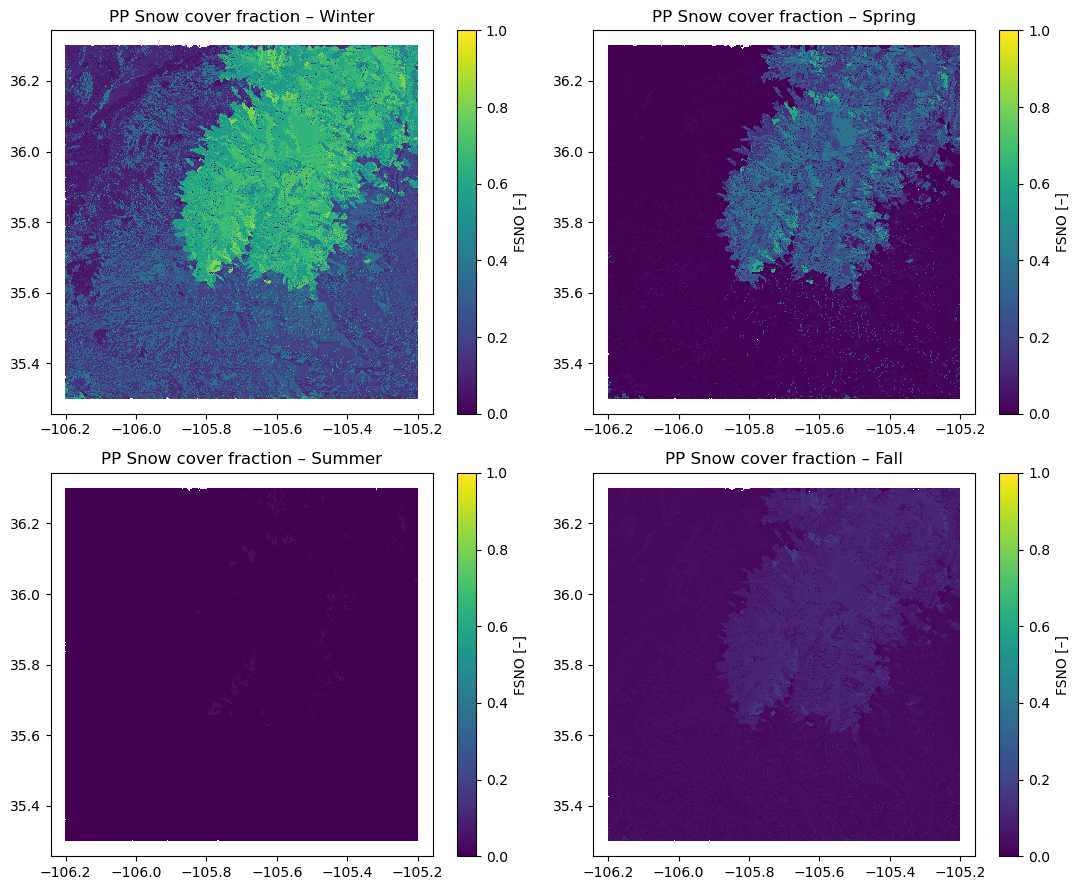

In [5]:
# snow cover fraction (fsno) seasonal plots

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus).astype(float)
tmp[:] = -9999.0

# If not already defined earlier
buffer = 250
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# -----------------------------
# Read output file once
# -----------------------------
fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
grp = fp.groups["data"]

fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
nt = fsno.shape[0]

fp.close()

# -----------------------------
# Build matching time vector
# -----------------------------
# Use the known start and 3-hourly timestep
start = pd.Timestamp("2016-01-01 00:00")
times = pd.date_range(start=start, periods=nt, freq="3H")

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    times_index = (
        (times.month == my_months[0]) |
        (times.month == my_months[1]) |
        (times.month == my_months[2])
    )

    data_sel = fsno[times_index, :]          # (time, hru)
    data_ave = np.nanmean(data_sel, axis=0)  # (hru,)

    final_map = place_data(tmp, data_ave, hrus, cids, 1)

    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"PP Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp_viridis_cmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [25]:
import os
import glob
import re
import pandas as pd

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

files = sorted(glob.glob(os.path.join(modscag_sat, "*.nc")))

dates = []
for f in files:
    name = os.path.basename(f)
    m = pat.match(name)
    if m:
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dates.append(pd.Timestamp(yyyy, mm, 1))

# Convert to dataframe for easy summary
df = pd.DataFrame({"date": dates})
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Total files:", len(df))
print("\nYears available:")
print(sorted(df["year"].unique()))

print("\nCounts per year:")
print(df.groupby("year").size())

print("\nCheck missing months per year:")
for y in sorted(df["year"].unique()):
    months = sorted(df[df["year"] == y]["month"].unique())
    missing = sorted(set(range(1,13)) - set(months))
    print(f"{y}: months={months} | missing={missing}")

Total files: 36

Years available:
[2016, 2017, 2018]

Counts per year:
year
2016    12
2017    12
2018    12
dtype: int64

Check missing months per year:
2016: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]
2017: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]
2018: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]


In [26]:
import netCDF4 as nc
import pandas as pd
import numpy as np

fp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
grp = fp.groups["data"]

# check one variable shape
fsno = np.array(grp.variables["fsno"][:])
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("ntime =", ntime)
print("start =", times.min())
print("end   =", times.max())
print("years =", sorted(pd.Index(times.year).unique()))

ntime = 8744
start = 2016-01-01 00:00:00
end   = 2018-12-28 21:00:00
years = [2016, 2017, 2018]


In [27]:
year_counts = pd.Series(times.year).value_counts().sort_index()
print(year_counts)

2016    2928
2017    2920
2018    2896
dtype: int64


In [28]:
df = pd.DataFrame({"time": times})
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

coverage = df.groupby(["year", "month"]).size().unstack(fill_value=0)
print(coverage)

month   1    2    3    4    5    6    7    8    9    10   11   12
year                                                             
2016   248  232  248  240  248  240  248  248  240  248  240  248
2017   248  224  248  240  248  240  248  248  240  248  240  248
2018   248  224  248  240  248  240  248  248  240  248  240  224


Processing SWE vs MODSCAG → Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1005705/2860302241.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing SWE vs MODSCAG → Spring
Processing SWE vs MODSCAG → Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1005705/2860302241.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing SWE vs MODSCAG → Fall


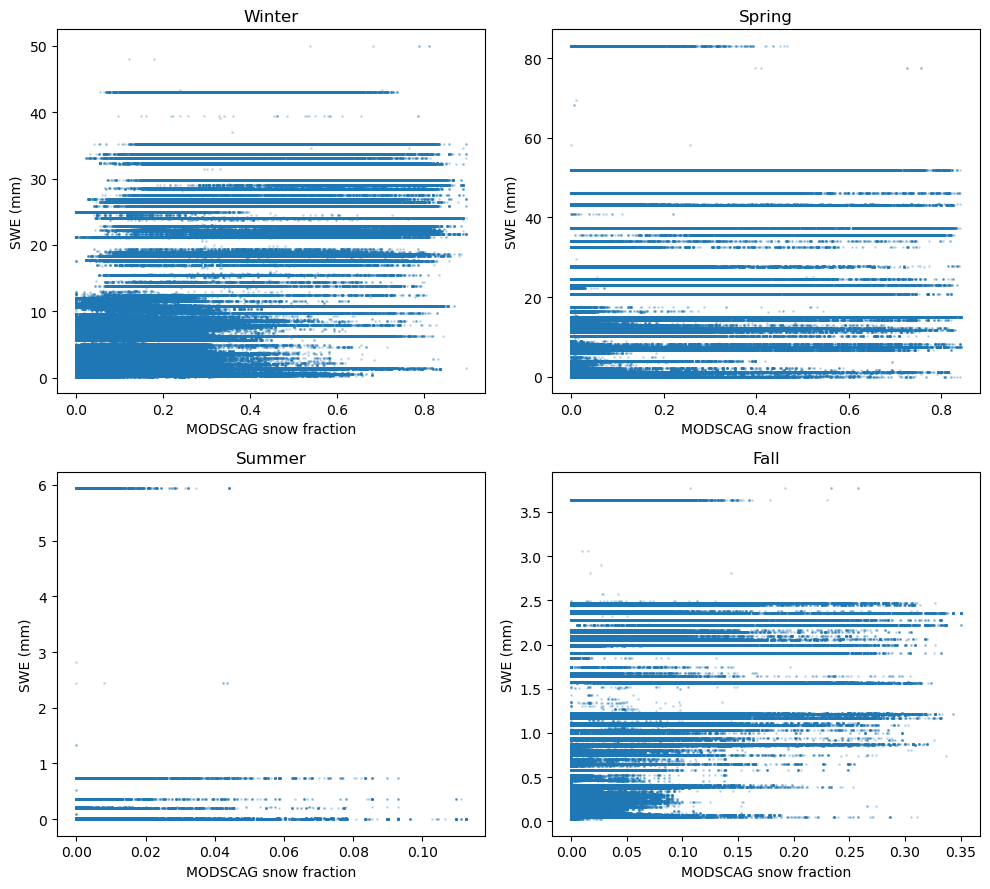

In [6]:
# ---------------------------------------
# SWE vs MODSCAG scatter (seasonal)
# ---------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ---- read SWE from model ----
fp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
grp = fp.groups["data"]

swe = np.array(grp.variables["swe"][:])   # (time, hru)
fp.close()

# ---- prepare figure ----
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    
    season = seasons[iss]
    months = season_months[iss]

    print(f"Processing SWE vs MODSCAG → {season}")

    # ---- time mask ----
    mask = ((times.dt.month == months[0]) |
            (times.dt.month == months[1]) |
            (times.dt.month == months[2]))

    swe_season = swe[mask, :]
    swe_mean = np.nanmean(swe_season, axis=0)  # (hru,)

    # ---- map SWE to grid ----
    swe_map = place_data(tmp, swe_mean, hrus, cids, 1)
    swe_map[swe_map == -9999] = np.nan

    swe_map = swe_map[
        buffer:swe_map.shape[0]-buffer+1,
        buffer:swe_map.shape[1]-buffer+1
    ]

    # ---- MODSCAG ----
    modscag_map = modscag_season_mean(modscag_rows, months)
    if modscag_map is None:
        ax.axis("off")
        continue

    modscag_map = modscag_map[
        buffer:modscag_map.shape[0]-buffer+1,
        buffer:modscag_map.shape[1]-buffer+1
    ]

    modscag_map = modscag_map / 100.0  # convert %

    # ---- flatten ----
    x = modscag_map.flatten()
    y = swe_map.flatten()

    mask_valid = np.isfinite(x) & np.isfinite(y)
    x = x[mask_valid]
    y = y[mask_valid]

    # ---- scatter ----
    ax.scatter(x, y, s=1, alpha=0.2)

    ax.set_title(season)
    ax.set_xlabel("MODSCAG snow fraction")
    ax.set_ylabel("SWE (mm)")

plt.tight_layout()
plt.show()

PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/
3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Output: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/test_K7


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2308970506.py:127: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


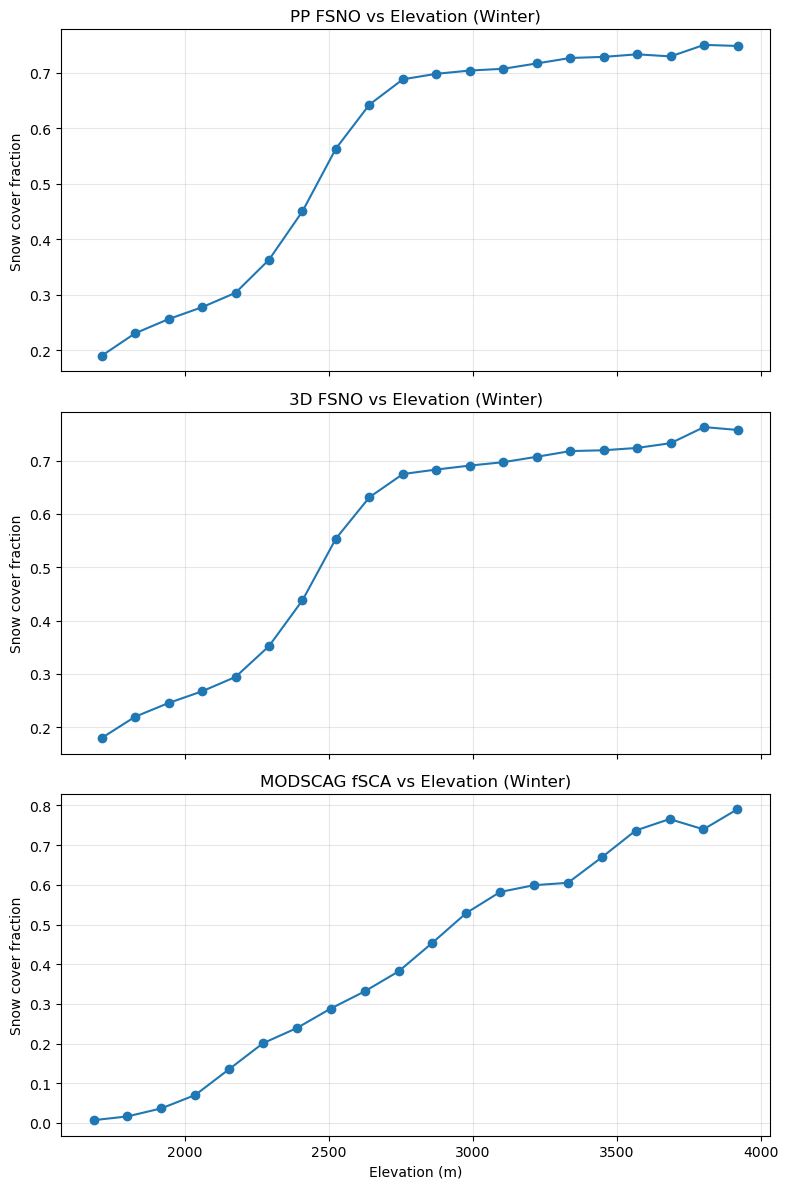

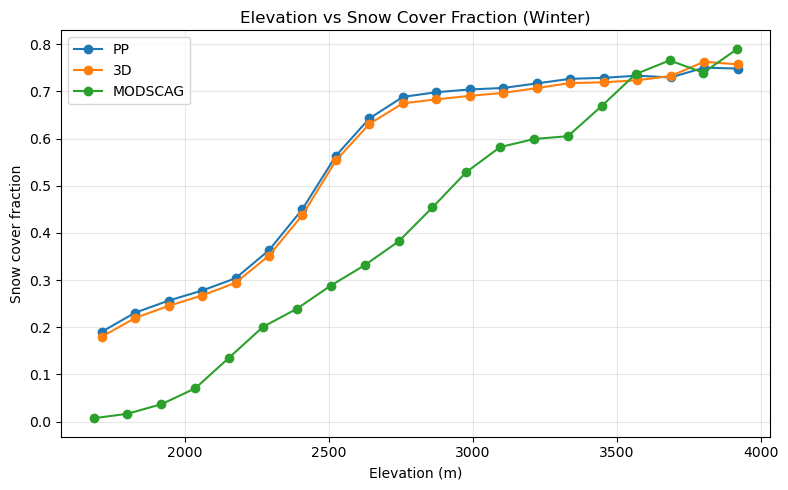

In [34]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import os, glob, re
import xarray as xr
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# PATHS
# ----------------------------
#path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/"
#path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/"

path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/'
path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_pp_para7/'
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/test_K7"
os.makedirs(outputdir, exist_ok=True)

print("PP:", path_pp)
print("3D:", path_3d)
print("MODSCAG:", modscag_sat)
print("Output:", outputdir)

# ----------------------------
# READ TIME FROM INPUT FILE
# ----------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00:00")
times = start + pd.to_timedelta(time, unit="h")
times = pd.DatetimeIndex(times).tz_localize("UTC").tz_convert("America/Denver")

# ----------------------------
# READ HRU / CID / DEM FROM ONE CONSISTENT GRID
# use PP grid as reference
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")
dem  = gdal_tools.read_raster(path_pp + "postprocess/dem.vrt")

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

# trim DEM to buffered domain
dem = dem[buffer:dem.shape[0]-buffer+1, buffer:dem.shape[1]-buffer+1]

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out


# MODSCAG filenames like: MODSCAG_HBclip_ALLVARS_201601_MODELGRID_4326.nc
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        # keep only 2016–2018 to match your current analysis period
        if dt.year < 2016 or dt.year > 2018:
            continue

        rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError(f"No MODSCAG monthly files found in {modscag_folder}")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()
    return arr


def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    return np.nanmean(np.stack(arrs, axis=0), axis=0)


def get_fsno_map(path_model, months):
    fp = nc.Dataset(path_model + "output_data/1/2016-01-01.nc")
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()

    month_vals = pd.to_datetime(times).month

    idx = ((month_vals == months[0]) |
           (month_vals == months[1]) |
           (month_vals == months[2]))

    fsno_sel = fsno[idx, :]
    fsno_avg = np.nanmean(fsno_sel, axis=0)

    map_out = place_data(tmp, fsno_avg, hrus, cids, 1)
    map_out = np.array(map_out, dtype=np.float32)
    map_out[map_out == -9999] = np.nan

    map_out = map_out[buffer:map_out.shape[0]-buffer+1,
                      buffer:map_out.shape[1]-buffer+1]

    return map_out


def elevation_profile(elev, snow, bins=20):
    mask = np.isfinite(elev) & np.isfinite(snow)

    elev_vals = elev[mask]
    snow_vals = snow[mask]

    bin_edges = np.linspace(np.nanmin(elev_vals), np.nanmax(elev_vals), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    means = []
    for i in range(bins):
        # include upper edge in last bin
        if i < bins - 1:
            idx = (elev_vals >= bin_edges[i]) & (elev_vals < bin_edges[i+1])
        else:
            idx = (elev_vals >= bin_edges[i]) & (elev_vals <= bin_edges[i+1])

        if np.sum(idx) > 0:
            means.append(np.nanmean(snow_vals[idx]))
        else:
            means.append(np.nan)

    return bin_centers, np.array(means)


# ----------------------------
# BUILD MODSCAG FILE LIST
# ----------------------------
modscag_rows = build_modscag_rows(modscag_sat)

# ----------------------------
# CHOOSE SEASON
# ----------------------------
months = (12, 1, 2)   # Winter

# ----------------------------
# GET MAPS
# ----------------------------
pp_map = get_fsno_map(path_pp, months)
map_3d = get_fsno_map(path_3d, months)
mod_map = modscag_season_mean(modscag_rows, months)

if mod_map is None:
    raise RuntimeError("No MODSCAG seasonal map could be created for selected months.")

# trim MODSCAG to same buffered domain
mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                  buffer:mod_map.shape[1]-buffer+1]

# convert MODSCAG percent -> fraction
mod_map = mod_map / 100.0

# ----------------------------
# ELEVATION PROFILES
# ----------------------------
elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

# ----------------------------
# 3 x 1 PLOT
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(elev_pp, prof_pp, "-o")
axes[0].set_title("PP FSNO vs Elevation (Winter)")
axes[0].set_ylabel("Snow cover fraction")
axes[0].grid(True, alpha=0.3)

axes[1].plot(elev_3d, prof_3d, "-o")
axes[1].set_title("3D FSNO vs Elevation (Winter)")
axes[1].set_ylabel("Snow cover fraction")
axes[1].grid(True, alpha=0.3)

axes[2].plot(elev_mod, prof_mod, "-o")
axes[2].set_title("MODSCAG fSCA vs Elevation (Winter)")
axes[2].set_ylabel("Snow cover fraction")
axes[2].set_xlabel("Elevation (m)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_profiles_3panel.png"), dpi=300)
plt.show()

# ----------------------------
# COMBINED PLOT
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(elev_pp, prof_pp, "-o", label="PP")
plt.plot(elev_3d, prof_3d, "-o", label="3D")
plt.plot(elev_mod, prof_mod, "-o", label="MODSCAG")

plt.xlabel("Elevation (m)")
plt.ylabel("Snow cover fraction")
plt.title("Elevation vs Snow Cover Fraction (Winter)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_combined.png"), dpi=300)
plt.show()

Processing Winter ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2308970506.py:127: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Spring ...
Processing Summer ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2290308/2308970506.py:127: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Fall ...


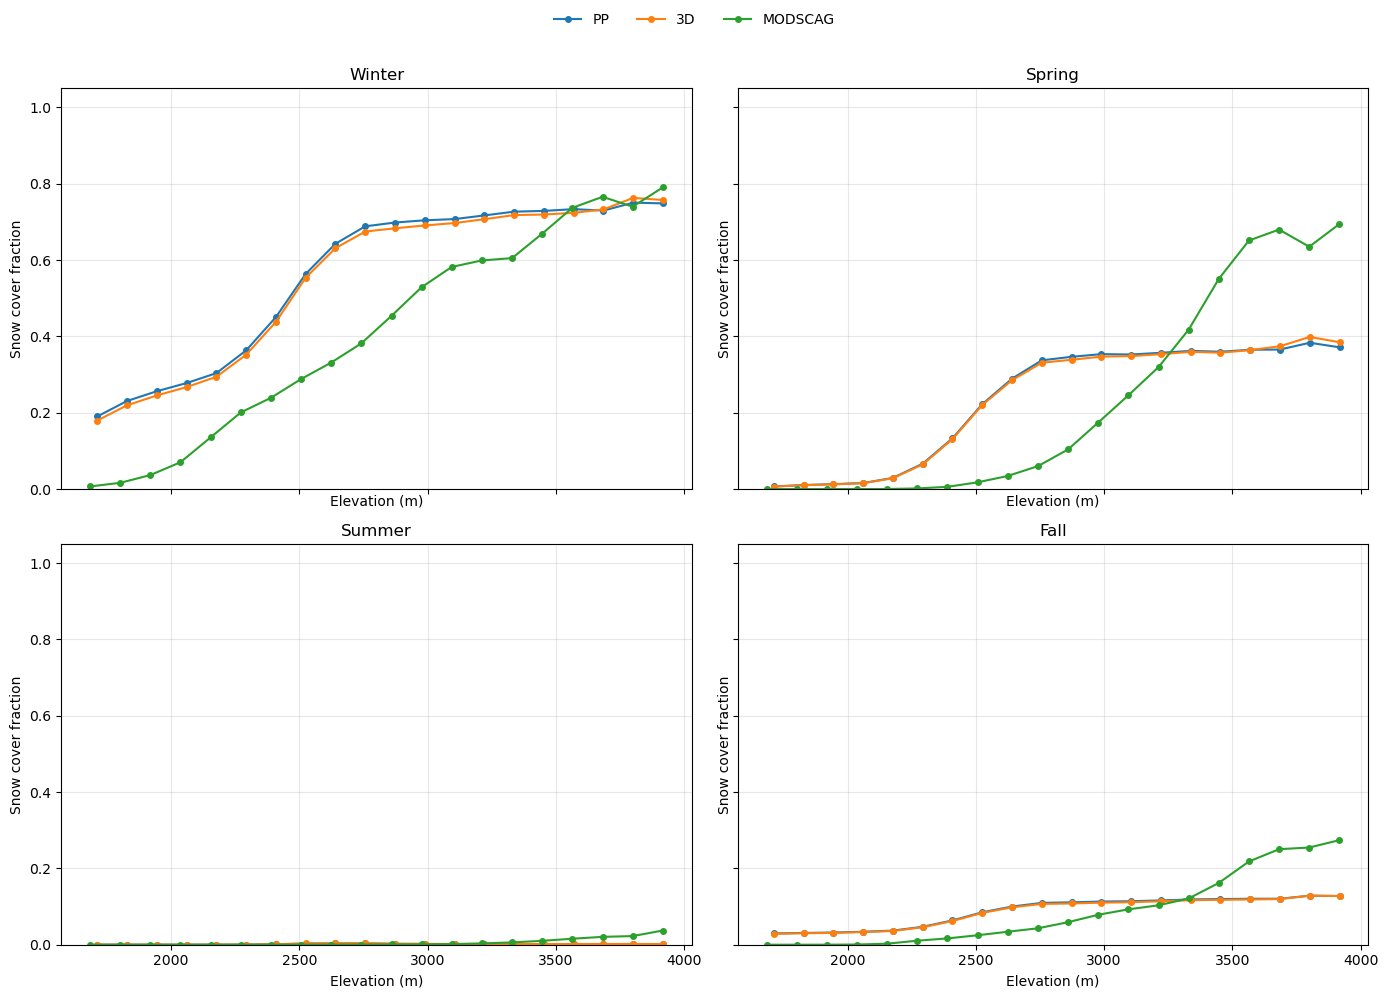

In [35]:
# ----------------------------
# PLOT ALL SEASONS: 2 x 2 GRID
# each panel shows PP, 3D, MODSCAG
# ----------------------------
season_dict = {
    "Winter": (12, 1, 2),
    "Spring": (3, 4, 5),
    "Summer": (6, 7, 8),
    "Fall":   (9, 10, 11),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (season_name, months) in zip(axes, season_dict.items()):
    print(f"Processing {season_name} ...")

    # get seasonal maps
    pp_map = get_fsno_map(path_pp, months)
    map_3d = get_fsno_map(path_3d, months)
    mod_map = modscag_season_mean(modscag_rows, months)

    if mod_map is None:
        ax.set_title(f"{season_name} (no MODSCAG data)")
        ax.axis("off")
        continue

    # trim MODSCAG to same buffered domain
    mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                      buffer:mod_map.shape[1]-buffer+1]

    # convert MODSCAG percent -> fraction
    mod_map = mod_map / 100.0

    # elevation profiles
    elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
    elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
    elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

    # plot all 3 curves in each season
    ax.plot(elev_pp,  prof_pp,  "-o", label="PP", markersize=4)
    ax.plot(elev_3d,  prof_3d,  "-o", label="3D", markersize=4)
    ax.plot(elev_mod, prof_mod, "-o", label="MODSCAG", markersize=4)

    ax.set_title(season_name)
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Snow cover fraction")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_all_seasons_2x2.png"), dpi=300)
plt.show()

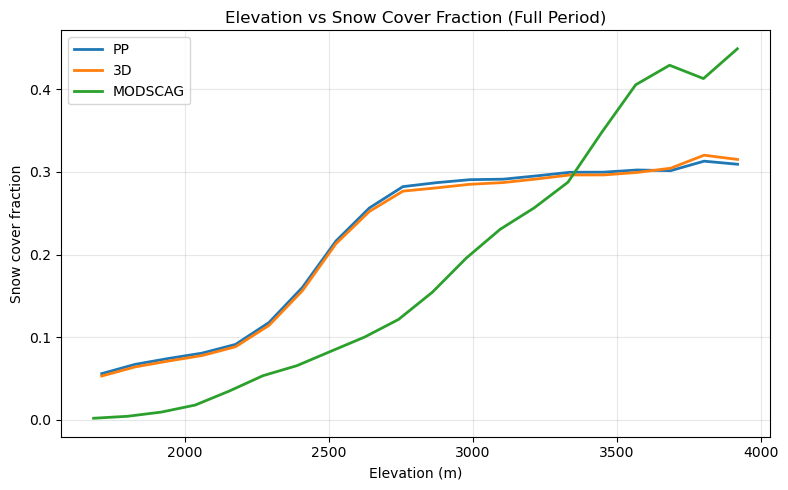

In [36]:
# ----------------------------
# FULL-PERIOD ELEVATION vs FSNO
# PP, 3D, MODSCAG on same plot
# ----------------------------

def get_fsno_map_fullperiod(path_model):
    fp = nc.Dataset(path_model + "output_data/1/2016-01-01.nc")
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()

    # mean over all time steps
    fsno_avg = np.nanmean(fsno, axis=0)

    # map HRU -> grid
    map_out = place_data(tmp, fsno_avg, hrus, cids, 1)
    map_out = np.array(map_out, dtype=np.float32)
    map_out[map_out == -9999] = np.nan

    # trim buffer
    map_out = map_out[buffer:map_out.shape[0]-buffer+1,
                      buffer:map_out.shape[1]-buffer+1]

    return map_out


def modscag_fullperiod_mean(rows):
    arrs = []
    for dt, fp in rows:
        arr = read_modscag_grid(fp)
        arr = arr.astype(np.float32)

        # trim buffer
        arr = arr[buffer:arr.shape[0]-buffer+1,
                  buffer:arr.shape[1]-buffer+1]

        # convert percent -> fraction
        arr = arr / 100.0

        arrs.append(arr)

    if len(arrs) == 0:
        return None

    return np.nanmean(np.stack(arrs, axis=0), axis=0)


# get full-period maps
pp_map  = get_fsno_map_fullperiod(path_pp)
map_3d  = get_fsno_map_fullperiod(path_3d)
mod_map = modscag_fullperiod_mean(modscag_rows)

if mod_map is None:
    raise RuntimeError("No MODSCAG data found for full-period mean.")

# elevation profiles
elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

# plot all three together
plt.figure(figsize=(8, 5))
plt.plot(elev_pp,  prof_pp,  "-", linewidth=2, label="PP")
plt.plot(elev_3d,  prof_3d,  "-", linewidth=2, label="3D")
plt.plot(elev_mod, prof_mod, "-", linewidth=2, label="MODSCAG")

plt.xlabel("Elevation (m)")
plt.ylabel("Snow cover fraction")
plt.title("Elevation vs Snow Cover Fraction (Full Period)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_fullperiod.png"), dpi=300)
plt.show()

Model path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
Creating classified model plot for Winter
Creating classified model plot for Spring
Creating classified model plot for Summer
Creating classified model plot for Fall


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


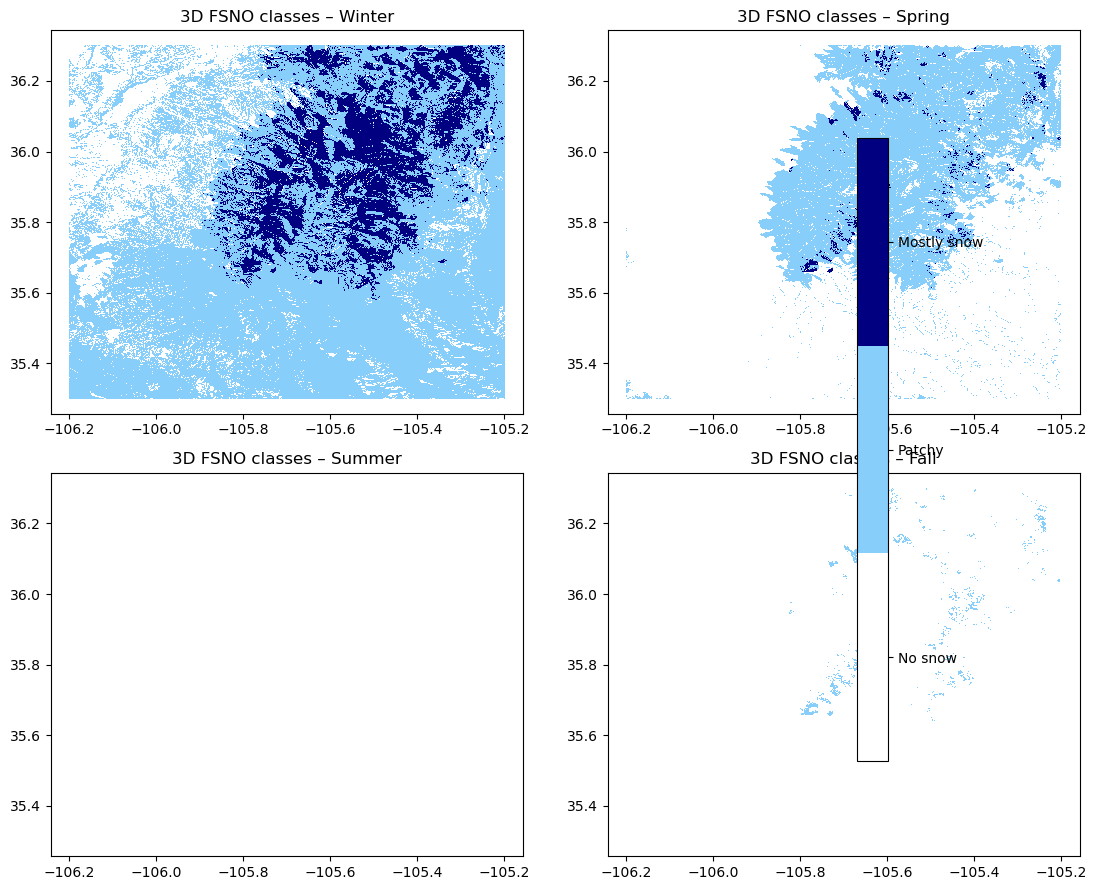

3d: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating class agreement plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:156: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating class agreement plot for Spring
Creating class agreement plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:156: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating class agreement plot for Fall


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


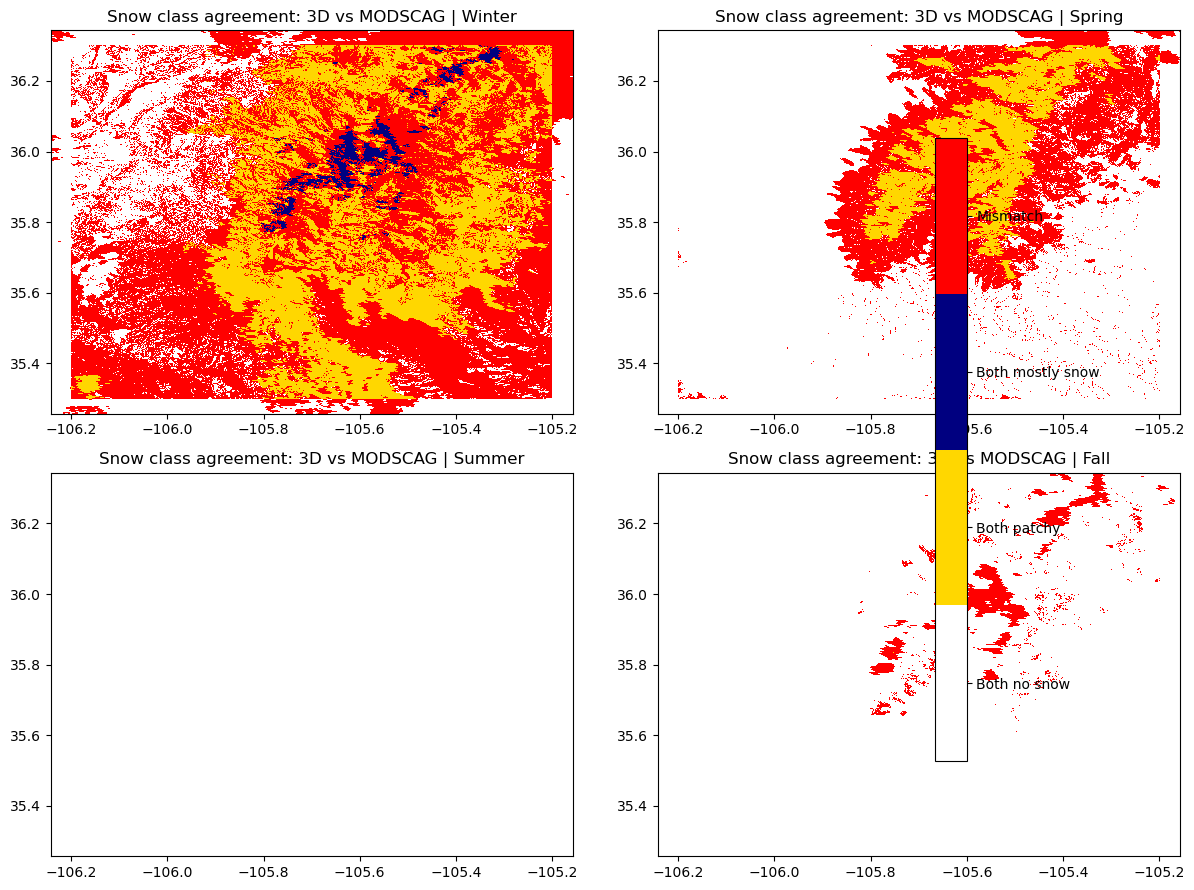

In [5]:
import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr

# =========================================================
# Snow class thresholds
# =========================================================
NO_SNOW_MAX = 0.15
PATCHY_MAX  = 0.7

def classify_snow(arr):
    """
    Convert fractional snow cover to classes:
      0 = no snow      (< 0.1)
      1 = patchy snow  (0.1 to 0.5)
      2 = mostly snow  (> 0.5)
    """
    out = np.full(arr.shape, np.nan, dtype="float32")

    valid = np.isfinite(arr)
    out[valid & (arr < NO_SNOW_MAX)] = 0
    out[valid & (arr >= NO_SNOW_MAX) & (arr <= PATCHY_MAX)] = 1
    out[valid & (arr > PATCHY_MAX)] = 2

    return out

# =========================================================
# Colormap for classes
# =========================================================
class_cmap = colors.ListedColormap(["white", "lightskyblue", "navy"])
class_norm = colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], class_cmap.N)

# =========================================================
# 1. Seasonal class maps for model FSNO
# =========================================================
path = path_3d
print("Model path:", path)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# read model once
fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating classified model plot for {my_season}")

    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    )

    data_sel = fsno[times_index, :]
    data_ave = np.nanmean(data_sel, axis=0)

    # map HRU to grid
    final_map = place_data(tmp, data_ave, hrus, cids, 1)
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    # classify
    class_map = classify_snow(final_map)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(class_map),
        cmap=class_cmap,
        norm=class_norm,
        shading="auto"
    )

    ax.set_title(f"3D FSNO classes – {my_season}")

cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2], shrink=0.9)
cbar.ax.set_yticklabels(["No snow", "Patchy", "Mostly snow"])

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_fsno_class_seasonal_3d.png"), dpi=300)
plt.show()

# =========================================================
# 2. Seasonal class agreement maps: Model vs MODSCAG
# =========================================================
print("3d:", path_3d)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

path = path_3d

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]
    da = da.where(da != 255)
    da = da.where(da != -9999)
    arr = da.values.astype("float32")
    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modscag_rows = build_modscag_rows(modscag_sat)

# agreement classes:
# 0 = both no snow
# 1 = both patchy
# 2 = both mostly snow
# 3 = mismatch
agree_cmap = colors.ListedColormap(["white", "gold", "navy", "red"])
agree_norm = colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], agree_cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

# read model once
fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
grp_3d = fp_3d.groups["data"]
fsno_3d = np.array(grp_3d.variables["fsno"][:])
fp_3d.close()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"Creating class agreement plot for {my_season}")

    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    )

    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)

    # model HRU -> grid
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d[map_3d == -9999] = np.nan

    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    # crop buffer
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert MODSCAG % to fraction
    modscag_map = modscag_map / 100.0

    # classify both
    class_model = classify_snow(map_3d)
    class_mod   = classify_snow(modscag_map)

    # agreement map
    agreement = np.full(class_model.shape, np.nan, dtype="float32")

    valid = np.isfinite(class_model) & np.isfinite(class_mod)

    agreement[valid & (class_model == 0) & (class_mod == 0)] = 0
    agreement[valid & (class_model == 1) & (class_mod == 1)] = 1
    agreement[valid & (class_model == 2) & (class_mod == 2)] = 2
    agreement[valid & (class_model != class_mod)] = 3

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(agreement),
        cmap=agree_cmap,
        norm=agree_norm,
        shading="auto"
    )

    ax.set_title(f"Snow class agreement: 3D vs MODSCAG | {my_season}")

cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2, 3], shrink=0.9)
cbar.ax.set_yticklabels(["Both no snow", "Both patchy", "Both mostly snow", "Mismatch"])

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_class_agreement_3d_vs_MODSCAG.png"), dpi=300)
plt.show()

In [7]:
valid = np.isfinite(map_3d) & np.isfinite(modscag_map)

snow_model = (map_3d > 0.15) & valid
snow_mod   = (modscag_map > 0.15) & valid

hit  = np.sum((snow_model == 1) & (snow_mod == 1))
miss = np.sum((snow_model == 0) & (snow_mod == 1))
false_alarm = np.sum((snow_model == 1) & (snow_mod == 0))

hit_rate = hit / (hit + miss) if (hit + miss) > 0 else np.nan
false_alarm_rate = false_alarm / (false_alarm + hit) if (false_alarm + hit) > 0 else np.nan

print("Hit rate:", hit_rate)
print("False alarm:", false_alarm_rate)

Hit rate: 0.0003654703603537753
False alarm: 0.9989692138537658


In [8]:
print("Model snow fraction:", np.mean(map_3d > 0.15))
print("MODSCAG snow fraction:", np.mean(modscag_map > 0.15))

Model snow fraction: 0.010092617380774369
MODSCAG snow fraction: 0.02575501237609161


In [9]:
valid = np.isfinite(map_3d) & np.isfinite(modscag_map)

model_snow_fraction = np.sum((map_3d > 0.15) & valid) / np.sum(valid)
modscag_snow_fraction = np.sum((modscag_map > 0.15) & valid) / np.sum(valid)

print("Model snow fraction (valid only):", model_snow_fraction)
print("MODSCAG snow fraction (valid only):", modscag_snow_fraction)

Model snow fraction (valid only): 0.010092617380774369
MODSCAG snow fraction (valid only): 0.028465592025778065


In [10]:
 valid = np.isfinite(map_3d) & np.isfinite(modscag_map)

snow_model = (map_3d > 0.15) & valid
snow_mod   = (modscag_map > 0.15) & valid

hit  = np.sum(snow_model & snow_mod)
miss = np.sum((~snow_model) & snow_mod)
false_alarm = np.sum(snow_model & (~snow_mod))
correct_negative = np.sum((~snow_model) & (~snow_mod) & valid)

hit_rate = hit / (hit + miss) if (hit + miss) > 0 else np.nan
false_alarm_rate = false_alarm / (false_alarm + hit) if (false_alarm + hit) > 0 else np.nan

print("Valid pixels:", np.sum(valid))
print("Hits:", hit)
print("Misses:", miss)
print("False alarms:", false_alarm)
print("Correct negatives:", correct_negative)
print("Hit rate:", hit_rate)
print("False alarm rate:", false_alarm_rate)

Valid pixels: 1441846
Hits: 15
Misses: 41028
False alarms: 14537
Correct negatives: 1386266
Hit rate: 0.0003654703603537753
False alarm rate: 0.9989692138537658


In [11]:
threshold = 0.15

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"\nSeason: {my_season}")

    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    )

    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)

    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d = map_3d.filled(np.nan)

    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        print("No MODSCAG data")
        continue

    # crop buffer
    map_3d = map_3d[buffer:map_3d.shape[0]-buffer+1, buffer:map_3d.shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert percent to fraction
    modscag_map = modscag_map / 100.0

    valid = np.isfinite(map_3d) & np.isfinite(modscag_map)

    snow_model = (map_3d > threshold) & valid
    snow_mod   = (modscag_map > threshold) & valid

    hit  = np.sum(snow_model & snow_mod)
    miss = np.sum((~snow_model) & snow_mod)
    false_alarm = np.sum(snow_model & (~snow_mod))
    correct_negative = np.sum((~snow_model) & (~snow_mod) & valid)

    hit_rate = hit / (hit + miss) if (hit + miss) > 0 else np.nan
    false_alarm_rate = false_alarm / (false_alarm + hit) if (false_alarm + hit) > 0 else np.nan

    model_snow_fraction = np.sum(snow_model) / np.sum(valid)
    modscag_snow_fraction = np.sum(snow_mod) / np.sum(valid)

    print("Valid pixels:", np.sum(valid))
    print("Model snow fraction:", model_snow_fraction)
    print("MODSCAG snow fraction:", modscag_snow_fraction)
    print("Hits:", hit)
    print("Misses:", miss)
    print("False alarms:", false_alarm)
    print("Correct negatives:", correct_negative)
    print("Hit rate:", hit_rate)
    print("False alarm rate:", false_alarm_rate)


Season: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:156: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Valid pixels: 1441742
Model snow fraction: 0.8104452807783917
MODSCAG snow fraction: 0.4901299955193093
Hits: 662495
Misses: 44146
False alarms: 505958
Correct negatives: 229143
Hit rate: 0.9375269762156455
False alarm rate: 0.4330152774651612

Season: Spring
Valid pixels: 1441846
Model snow fraction: 0.30468649217738925
MODSCAG snow fraction: 0.11706035179901321
Hits: 156651
Misses: 12132
False alarms: 282660
Correct negatives: 990403
Hit rate: 0.9281207230586018
False alarm rate: 0.6434166228480507

Season: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_155965/2505960340.py:156: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Valid pixels: 1441846
Model snow fraction: 0.0
MODSCAG snow fraction: 0.0
Hits: 0
Misses: 0
False alarms: 0
Correct negatives: 1441846
Hit rate: nan
False alarm rate: nan

Season: Fall
Valid pixels: 1441846
Model snow fraction: 0.010092617380774369
MODSCAG snow fraction: 0.028465592025778065
Hits: 15
Misses: 41028
False alarms: 14537
Correct negatives: 1386266
Hit rate: 0.0003654703603537753
False alarm rate: 0.9989692138537658


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


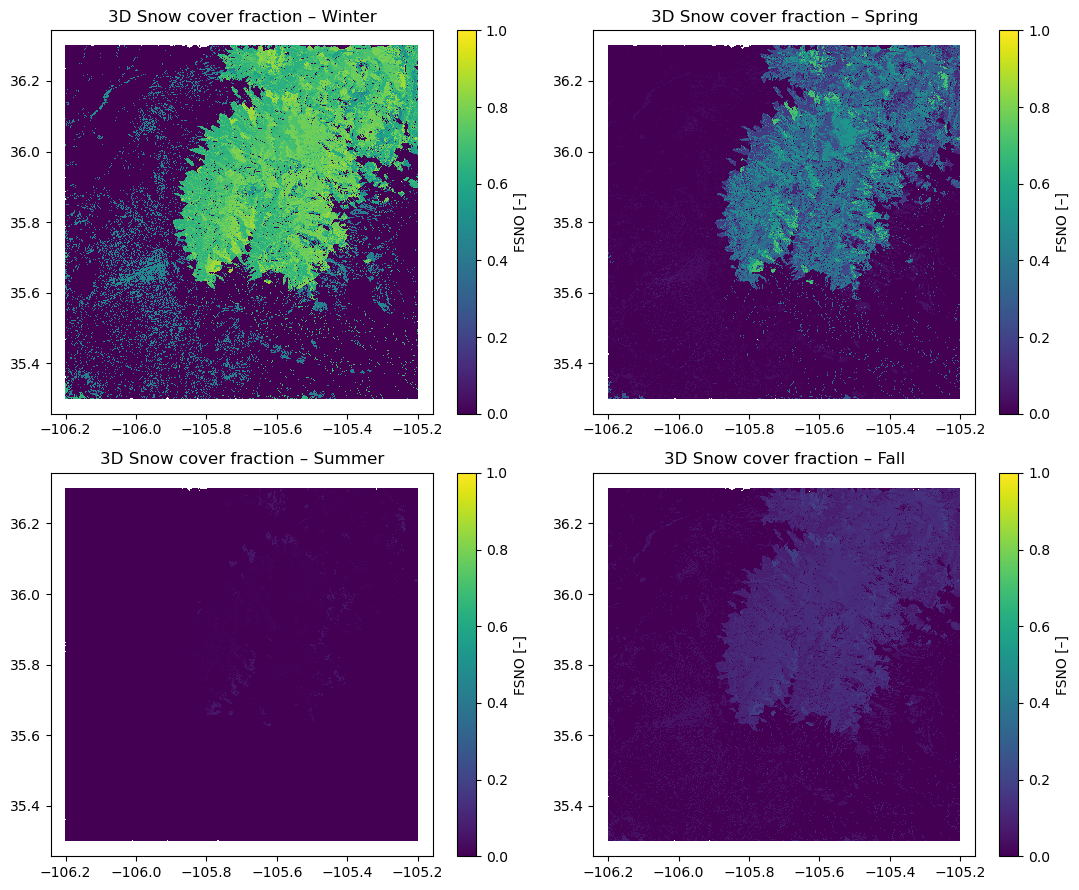

In [14]:
# snow cover fraction (fsno) seasonal plots

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# fixed color scale
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

# -----------------------------
# Read file once
# -----------------------------
c = 1
fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
grp = fp.groups["data"]

fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

# -----------------------------
# Annual mask based on paper:
# exclude grids where annual fsno < 0.05
# -----------------------------
annual_fsno_mean = np.nanmean(fsno, axis=0)      # (hru,)
snow_mask = annual_fsno_mean >= 0.12             # True where retained

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    # Seasonal mask in time
    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    )

    # Seasonal mean over time
    data_sel = fsno[times_index, :]              # (time, hru)
    data_ave = np.nanmean(data_sel, axis=0)      # (hru,)

    # Apply annual snow mask
    data_ave[~snow_mask] = 0.00

    # Map HRU values to grid
    final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask fill values
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map.astype(float)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"3D Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_3d_masked_annualgt005.png"),
    dpi=300
)
plt.show()

3d: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating differences plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_519177/2149475726.py:72: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Spring
Creating differences plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_519177/2149475726.py:72: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Fall


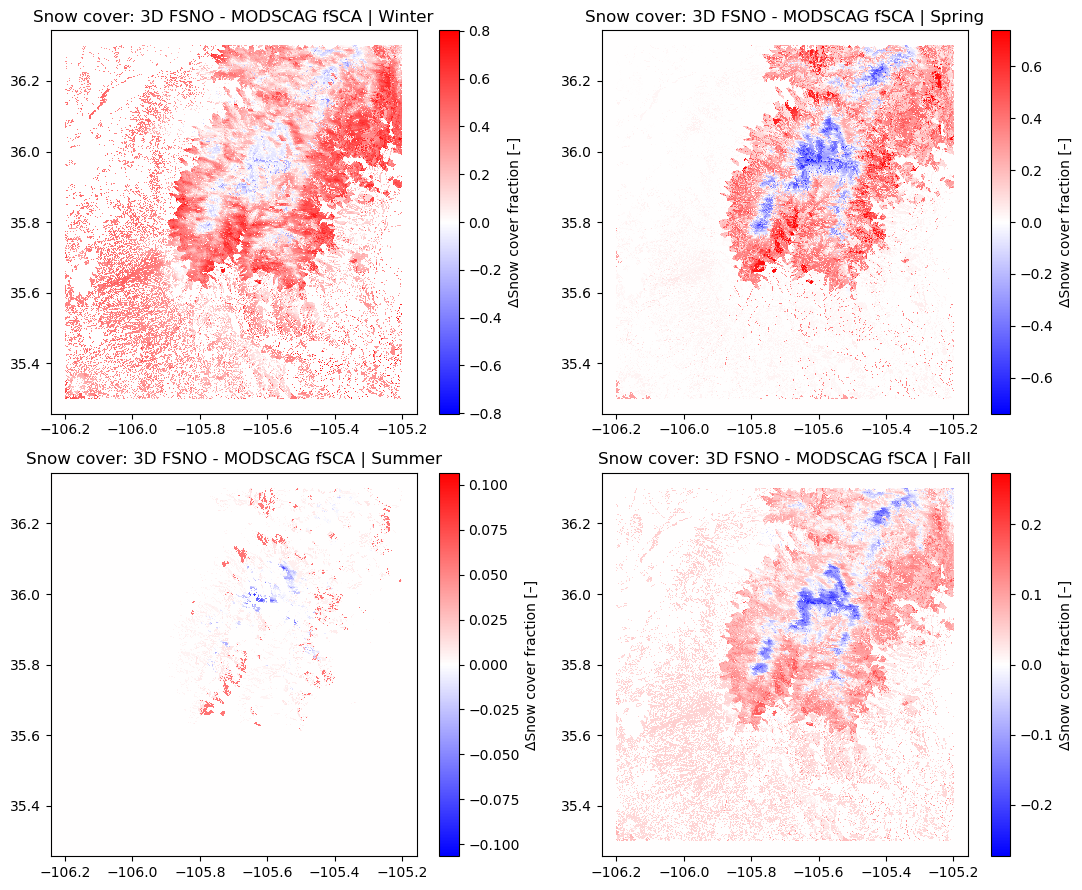

In [11]:
# 3d - modscag seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO - MODSCAG fSCA
# Apply annual fsno threshold: keep only cells with annual model fsno >= 0.05
# Excluded cells are plotted as 0 difference (center color)

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr

print("3d:", path_3d)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# use 3d domain for mapping
path = path_3d

# read mapping rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODSCAG monthly files
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

# -----------------------------
# Read model fsno once
# -----------------------------
fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
grp_3d = fp_3d.groups["data"]
fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
fp_3d.close()

# -----------------------------
# Annual threshold mask from model fsno
# keep only cells with annual fsno >= 0.05
# -----------------------------
annual_fsno_3d = np.nanmean(fsno_3d, axis=0)      # (hru,)
snow_mask_hru = annual_fsno_3d >= 0.10

modscag_rows = build_modscag_rows(modscag_sat)

# optional: force NaNs to center color if any sneak in
cmap = plt.cm.bwr.copy()
cmap.set_bad(color=cmap(0.5))

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # seasonal mask
    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    )

    # 3d seasonal mean FSNO in HRU space
    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)   # (hru,)

    # apply annual threshold in HRU space
    fsno_3d_ave[~snow_mask_hru] = 0.0

    # map model HRU -> grid
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = map_3d.astype(float)
    map_3d[map_3d == -9999] = 0.0

    # MODSCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    modscag_map = modscag_map.astype(float)

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[
        buffer:map_shape[0]-buffer+1,
        buffer:map_shape[1]-buffer+1
    ]
    modscag_map = modscag_map[
        buffer:modscag_map.shape[0]-buffer+1,
        buffer:modscag_map.shape[1]-buffer+1
    ]

    # convert MODSCAG % -> fraction
    modscag_map = modscag_map / 100.0

    # apply same threshold to MODSCAG side using model-based mask on mapped grid
    valid_mask_grid = map_3d > 0.0
    modscag_map[~valid_mask_grid] = 0.0

    # difference: 3d - MODSCAG
    final_map = map_3d - modscag_map

    # excluded cells should stay at 0 difference
    final_map[~valid_mask_grid] = 0.0

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap=cmap,
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title("Snow cover: 3D FSNO - MODSCAG fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_snow_3d_minus_MODSCAG_fSCA_maps_threshold005.png"),
    dpi=300
)
plt.show()

MODSCAG vs 3D: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_519177/1014313908.py:22: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


MODSCAG vs 3D: Spring
MODSCAG vs 3D: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_519177/1014313908.py:22: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


MODSCAG vs 3D: Fall


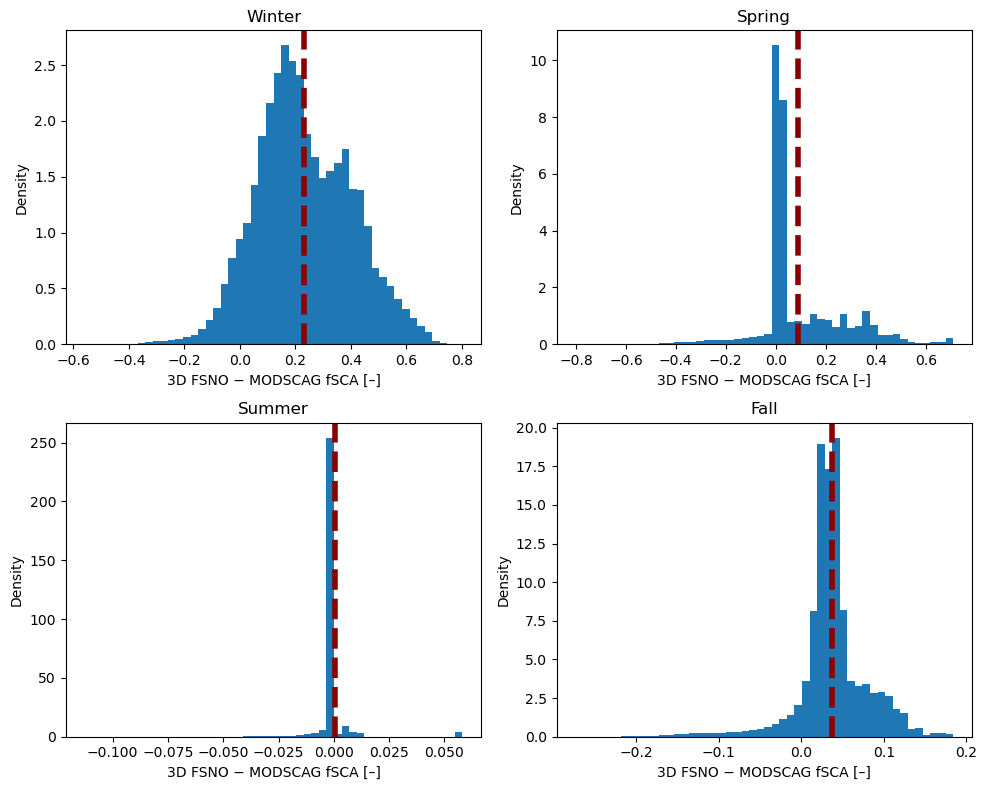

In [13]:
# 3D vs MODSCAG difference Histogram Plot (Snow cover fraction)
# Difference = 3D FSNO - MODSCAG fSCA
# Snow-related threshold: keep only cells where annual 3D fsno >= 0.05

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

path_domain = path_3d

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modscag_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No MODSCAG files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# -----------------------------
# Read 3D fsno once
# -----------------------------
fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
fp_3d.close()

# -----------------------------
# Annual threshold mask in HRU space
# keep only annual fsno >= 0.05
# -----------------------------
annual_fsno_3d = np.nanmean(fsno_3d, axis=0)      # (hru,)
snow_mask_hru = np.where(annual_fsno_3d >= 0.05, 1.0, np.nan)

# map HRU snow mask to grid once
snow_mask_grid = place_data(tmp, snow_mask_hru, hrus, cids, 1)
snow_mask_grid = np.where(snow_mask_grid == -9999, np.nan, snow_mask_grid)
snow_mask_grid = snow_mask_grid[buffer:-buffer+1, buffer:-buffer+1]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"MODSCAG vs 3D: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # 3D seasonal mean FSNO (HRU space)
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)

    # map 3D HRU -> grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # MODSCAG seasonal mean (grid, already on model grid)
    modscag_grid = modscag_season_mean_grid(modscag_rows, my_months)
    modscag_grid = modscag_grid / 100.0   # percent -> fraction
    modscag_grid = modscag_grid[buffer:-buffer+1, buffer:-buffer+1]

    # apply same snow-analysis mask to both
    fsno_3d_grid = np.where(np.isfinite(snow_mask_grid), fsno_3d_grid, np.nan)
    modscag_grid = np.where(np.isfinite(snow_mask_grid), modscag_grid, np.nan)

    # difference
    diff = fsno_3d_grid - modscag_grid

    # histogram values
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        ax.set_title(my_season)
        ax.text(0.5, 0.5, "No valid cells", ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel("3D FSNO − MODSCAG fSCA [–]")
        continue

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − MODSCAG fSCA [–]")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_snow_3D_minus_MODSCAG_fSCA_threshold005.png"),
    dpi=300
)
plt.show()